In [57]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [58]:
X, y = make_circles(n_samples = 1000, random_state = 42, noise = 0.03)

In [59]:
df = pd.DataFrame(X, y)
X.shape, y.shape

((1000, 2), (1000,))

In [60]:
X_reduced = PCA(n_components = 2).fit_transform(X)

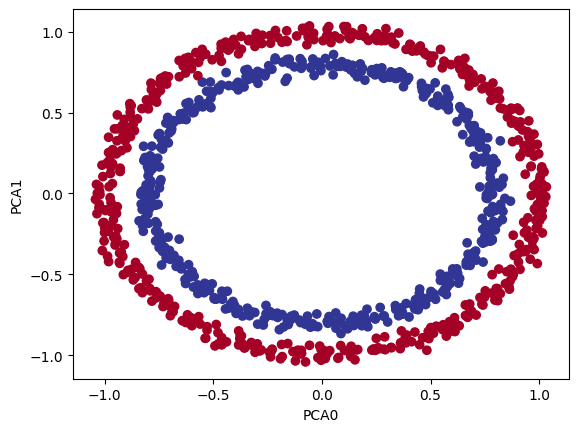

In [61]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("PCA0")
plt.ylabel("PCA1")
plt.show()

In [62]:
## Turning ndarray(numpy array) into torch.tensor

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [63]:
# Train,Test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [64]:
torch.abs(X_train[:5])

tensor([[0.6579, 0.4651],
        [0.6319, 0.7347],
        [1.0086, 0.1240],
        [0.9666, 0.2256],
        [0.1666, 0.7994]])

In [65]:
X_train.shape

torch.Size([800, 2])

In [66]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [67]:
class MultiLayerClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()

        ## Linear Layer (multi)
        self.layer_1 = torch.nn.Linear(
            in_features = 2, out_features = 5,
        )

        self.layer_2 = torch.nn.Linear(
            in_features = 5, out_features = 1
        )

        ## Method 2 (sequential layer)
        # self.seq_layer = torch.nn.Sequential(
        #     torch.nn.Linear(
        #         in_features = 2, out_features = 5
        #    ),
        #     torch.nn.Linear(
        #         in_features = 5, out_features = 1
        #     )
        # )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_2(self.layer_1(x))

In [68]:
model = MultiLayerClassifier().to(device)
model

MultiLayerClassifier(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [69]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.6459,  0.1048],
                      [ 0.1937,  0.2871],
                      [-0.6788,  0.4732],
                      [ 0.0204, -0.0664],
                      [-0.6763, -0.6779]], device='mps:0')),
             ('layer_1.bias',
              tensor([ 0.6458,  0.3867,  0.3320,  0.6029, -0.4066], device='mps:0')),
             ('layer_2.weight',
              tensor([[-0.1498, -0.2690,  0.4102,  0.1607,  0.2906]], device='mps:0')),
             ('layer_2.bias', tensor([0.3046], device='mps:0'))])

In [70]:
with torch.inference_mode():
    y_pred = model(X_test.to(device))

In [71]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.6459,  0.1048],
                      [ 0.1937,  0.2871],
                      [-0.6788,  0.4732],
                      [ 0.0204, -0.0664],
                      [-0.6763, -0.6779]], device='mps:0')),
             ('layer_1.bias',
              tensor([ 0.6458,  0.3867,  0.3320,  0.6029, -0.4066], device='mps:0')),
             ('layer_2.weight',
              tensor([[-0.1498, -0.2690,  0.4102,  0.1607,  0.2906]], device='mps:0')),
             ('layer_2.bias', tensor([0.3046], device='mps:0'))])

In [72]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [73]:
def accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct/len(y_pred)) * 100

In [74]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test.to(device))

y_logits[:5]

tensor([[0.3788],
        [0.1070],
        [0.6883],
        [0.2928],
        [0.0483]], device='mps:0')

In [75]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [78]:
_y_label = torch.round(y_logits[:5])
torch.eq(y_test[:5].to(device), _y_label[:5]) 

tensor([[False,  True, False,  True, False],
        [False,  True, False,  True, False],
        [ True, False,  True, False,  True],
        [False,  True, False,  True, False],
        [False,  True, False,  True, False]], device='mps:0')

In [90]:
y_preds_prob = model(X_train.to(device)).sigmoid()
torch.round(y_preds_prob[:5]).squeeze()

tensor([0., 0., 1., 1., 1.], device='mps:0', grad_fn=<SqueezeBackward0>)

In [85]:
y_preds_logit = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))
y_preds_logit.squeeze()

tensor([1., 1., 1., 1., 1.], device='mps:0', grad_fn=<SqueezeBackward0>)

In [104]:
torch.mps.manual_seed(42)
torch.manual_seed(42)

In [99]:
epochs = 100
epoch_loop = []
losses = []
test_losses = []

## Training Loop
for epoch in range(epochs):
    model.train()

    ## 1. Forward Pass
    y_pred_probs = model(X_train.to(device))
    y_pred = torch.round(torch.sigmoid(y_pred_probs)).squeeze()

    ## 2. Calculating Model Accuracy
    model_acc = accuracy(y_train, y_pred)

    ## 3. Loss & Optimization
    loss = loss_fn(y_pred, y_train.to(device))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    epoch_loop.append(epoch)

In [102]:
X_train[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]])

/var/folders/4k/m7f5dtm96j744jvsqr8rndw80000gn/T/ipykernel_26904/168213779.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_logits = model(torch.tensor(X_test, dtype=torch.float32).to(device))


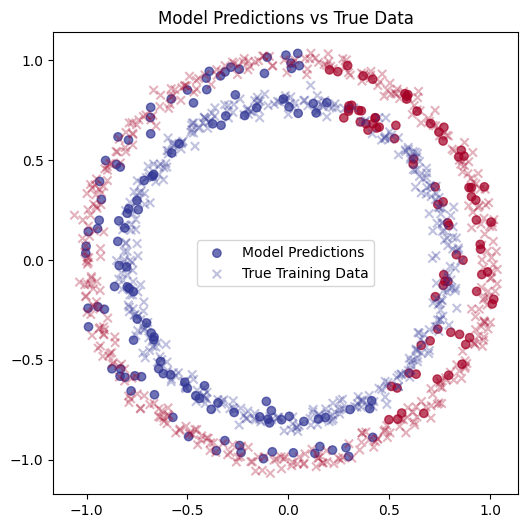

In [92]:
with torch.inference_mode():
    y_logits = model(torch.tensor(X_test, dtype=torch.float32).to(device))
    y_pred = torch.round(torch.sigmoid(y_logits)).cpu().numpy().squeeze()

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap=plt.cm.RdYlBu, label="Model Predictions", alpha=0.7)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, label="True Training Data", alpha=0.3, marker="x")
plt.legend()
plt.title("Model Predictions vs True Data")
plt.show()